In [ ]:
import numpy as np
import pandas as pd
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("All good!")

numpy: 2.2.6
pandas: 2.3.3
All good!


In [ ]:
from rdkit import Chem
print("rdkit works!")

rdkit works!


In [ ]:
import subprocess
subprocess.run(["pip", "install", "matminer"], check=True)

CompletedProcess(args=['pip', 'install', 'matminer'], returncode=0)

In [ ]:
from matminer.datasets import load_dataset
df = load_dataset("dielectric_constant")
print(df.shape)
print(df.columns.tolist())
print(df.head())

(1056, 16)
['material_id', 'formula', 'nsites', 'space_group', 'volume', 'structure', 'band_gap', 'e_electronic', 'e_total', 'n', 'poly_electronic', 'poly_total', 'pot_ferroelectric', 'cif', 'meta', 'poscar']
  material_id formula  nsites  space_group      volume  \
0      mp-441   Rb2Te       3          225  159.501208   
1    mp-22881   CdCl2       3          166   84.298097   
2    mp-28013    MnI2       3          164  108.335875   
3   mp-567290     LaN       4          186   88.162562   
4   mp-560902    MnF2       6          136   82.826401   

                                           structure  band_gap  \
0  [[1.75725875 1.2425695  3.04366125] Rb, [5.271...      1.88   
1  [[0. 0. 0.] Cd, [ 4.27210959  2.64061969 13.13...      3.52   
2  [[0. 0. 0.] Mn, [-2.07904300e-06  2.40067320e+...      1.17   
3  [[-1.73309900e-06  2.38611186e+00  5.95256328e...      1.12   
4  [[1.677294 2.484476 2.484476] Mn, [0. 0. 0.] M...      2.87   

                                        e_ele

In [ ]:
print(df["band_gap"].describe())
print(f"Rows with band_gap > 0: {(df['band_gap'] > 0).sum()}")

count    1056.000000
mean        2.119432
std         1.604924
min         0.110000
25%         0.890000
50%         1.730000
75%         2.885000
max         8.320000
Name: band_gap, dtype: float64
Rows with band_gap > 0: 1056


In [ ]:
df_raw = pd.read_csv("data/polymers.csv")
print(df_raw.columns.tolist())
print(df_raw.head(2))

['material_id', 'formula', 'nsites', 'space_group', 'volume', 'structure', 'band_gap', 'e_electronic', 'e_total', 'n', 'poly_electronic', 'poly_total', 'pot_ferroelectric', 'cif', 'meta', 'poscar']
  material_id formula  nsites  space_group      volume  \
0      mp-441   Rb2Te       3          225  159.501208   
1    mp-22881   CdCl2       3          166   84.298097   

                                           structure  band_gap  \
0  Full Formula (Rb2 Te1)\nReduced Formula: Rb2Te...      1.88   
1  Full Formula (Cd1 Cl2)\nReduced Formula: CdCl2...      3.52   

                                        e_electronic  \
0  [[3.44115795, -3.097e-05, -6.276e-05], [-2.837...   
1  [[3.34688382, -0.04498543, -0.22379197], [-0.0...   

                                             e_total     n  poly_electronic  \
0  [[6.23414745, -0.00035252, -9.796e-05], [-0.00...  1.86             3.44   
1  [[7.97018673, -0.29423886, -1.463590159999999]...  1.78             3.16   

   poly_total  pot_fe

In [ ]:
import os
os.makedirs("data", exist_ok=True)
df.to_csv("data/polymers.csv", index=False)
print("Saved!")

Saved!


In [ ]:
from matminer.featurizers.composition import ElementProperty
from pymatgen.core import Composition

def formula_to_features(formula_list):
    """Convert chemical formula to ElementProperty features."""
    featurizer = ElementProperty.from_preset("magpie")
    rows = []
    for formula in formula_list:
        try:
            comp = Composition(formula)
            features = featurizer.featurize(comp)
            rows.append(features)
        except:
            rows.append([0] * len(featurizer.feature_labels()))
    return np.array(rows)
def objective(trial, X_tr, y_tr):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 200),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "random_state": SEED,
        "verbosity": -1,
    }
    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    rmses = []
    for tr_idx, val_idx in kf.split(X_tr):
        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr[tr_idx], y_tr[tr_idx],
                  eval_set=[(X_tr[val_idx], y_tr[val_idx])],
                  callbacks=[lgb.early_stopping(50, verbose=False)])
        preds = model.predict(X_tr[val_idx])
        rmses.append(mean_squared_error(y_tr[val_idx], preds) ** 0.5)
    return np.mean(rmses)

def main(args):
    df = pd.read_csv(args.data_path).dropna(subset=["formula", "band_gap"])
    df = df[df["band_gap"] > 0].reset_index(drop=True)

    print(f"Dataset size: {len(df)} rows")

    X = formula_to_features(df["formula"].tolist())
    y = df["band_gap"].values

    # Replace NaN with median
    X = pd.DataFrame(X).fillna(pd.DataFrame(X).median()).values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.15, random_state=SEED
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.15, random_state=SEED
    )

    print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

    mlflow.set_experiment("bandgap_prediction")
    with mlflow.start_run():
        study = optuna.create_study(direction="minimize",
                                    sampler=optuna.samplers.TPESampler(seed=SEED))
        study.optimize(lambda t: objective(t, X_train, y_train),
                       n_trials=args.n_trials)

        best_params = study.best_params
        best_params.update({"random_state": SEED, "verbosity": -1})
        mlflow.log_params(best_params)

        final_model = lgb.LGBMRegressor(**best_params)
        final_model.fit(X_train, y_train,
                        eval_set=[(X_val, y_val)],
                        callbacks=[lgb.early_stopping(50, verbose=False),
                                   lgb.log_evaluation(50)])

        val_preds = final_model.predict(X_val)
        val_rmse = mean_squared_error(y_val, val_preds) ** 0.5
        val_r2   = r2_score(y_val, val_preds)
        mlflow.log_metrics({"val_rmse": val_rmse, "val_r2": val_r2})
        print(f"[val] RMSE={val_rmse:.4f}  R2={val_r2:.4f}")

        os.makedirs("checkpoints", exist_ok=True)
        final_model.booster_.save_model("checkpoints/lgbm_bandgap_best.txt")
        print("Model saved to checkpoints/lgbm_bandgap_best.txt")
        return final_model, X_val, y_val

In [ ]:
class Args:
    data_path = "data/polymers.csv"
    n_trials = 5

args = Args()
final_model, X_val, y_val = main(args)

Dataset size: 1056 rows


c:\Users\suhai\anaconda3\envs\bandgap\lib\site-packages\matminer\utils\data.py:326: UserWarning: MagpieData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)
[I 2026-03-16 01:27:25,739] A new study created in memory with name: no-name-3f0924ab-82a3-427c-997f-c3caece90009


Train: 762, Val: 135, Test: 159


c:\Users\suhai\anaconda3\envs\bandgap\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\suhai\anaconda3\envs\bandgap\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\suhai\anaconda3\envs\bandgap\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\suhai\anaconda3\envs\bandgap\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\suhai\anaconda3\envs\bandgap\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with featur

[50]	valid_0's l2: 1.2198
[100]	valid_0's l2: 0.829796
[150]	valid_0's l2: 0.676578
[200]	valid_0's l2: 0.620372
[250]	valid_0's l2: 0.593692
[300]	valid_0's l2: 0.57287
[350]	valid_0's l2: 0.555037
[400]	valid_0's l2: 0.541647
[450]	valid_0's l2: 0.53053
[500]	valid_0's l2: 0.521521
[550]	valid_0's l2: 0.515902
[600]	valid_0's l2: 0.512628
[650]	valid_0's l2: 0.509549
[val] RMSE=0.7122  R2=0.8014
Model saved to checkpoints/lgbm_bandgap_best.txt


c:\Users\suhai\anaconda3\envs\bandgap\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


C:\Users\suhai\AppData\Local\Temp\ipykernel_420\3221900587.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_val[:100], show=False)


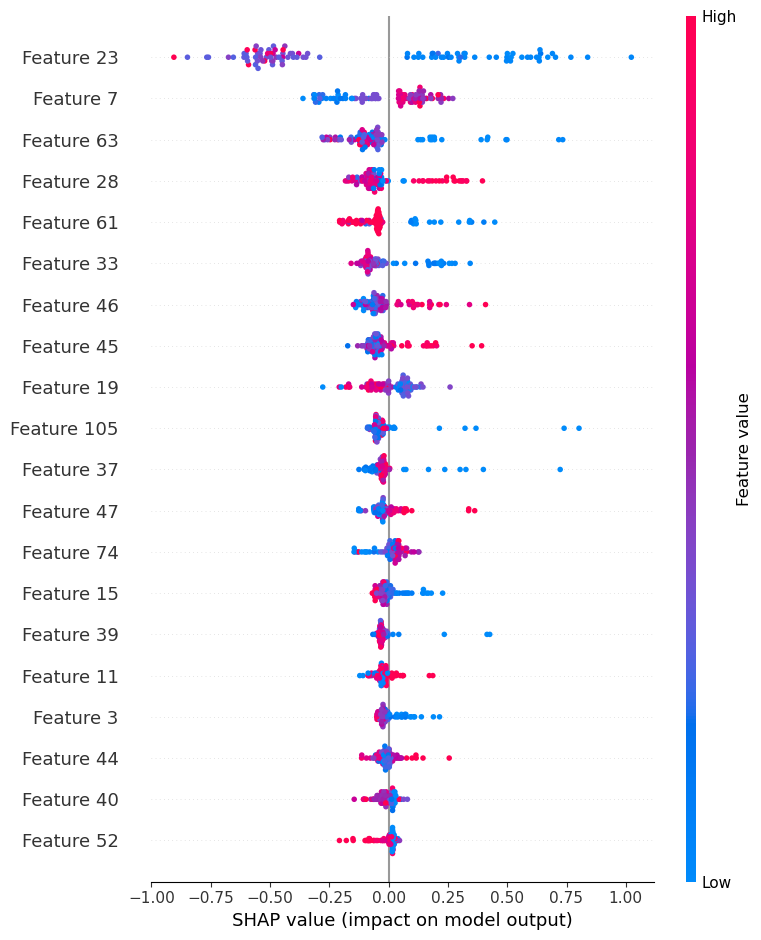

SHAP plot saved!


In [ ]:
import shap
import matplotlib.pyplot as plt
import os

os.makedirs("reports", exist_ok=True)

explainer = shap.TreeExplainer(final_model)
shap_vals = explainer.shap_values(X_val[:100])

shap.summary_plot(shap_vals, X_val[:100], show=False)
plt.savefig("reports/shap_beeswarm.png", bbox_inches="tight", dpi=150)
plt.show()
print("SHAP plot saved!")

In [ ]:
from matminer.featurizers.composition import ElementProperty

featurizer = ElementProperty.from_preset("magpie")
feature_names = featurizer.feature_labels()

print("Feature 23 =", feature_names[23])
print("Feature 7 =", feature_names[7])
print("Feature 63 =", feature_names[63])

Feature 23 = MagpieData mode MeltingT
Feature 7 = MagpieData maximum MendeleevNumber
Feature 63 = MagpieData mean NdValence


c:\Users\suhai\anaconda3\envs\bandgap\lib\site-packages\matminer\utils\data.py:326: UserWarning: MagpieData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)


c:\Users\suhai\anaconda3\envs\bandgap\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


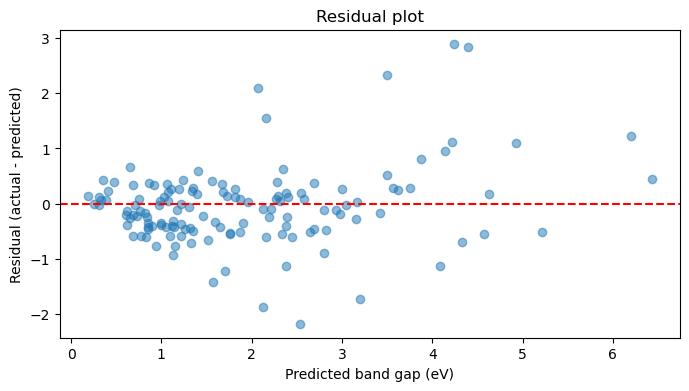

Residual plot saved!


In [ ]:
val_preds = final_model.predict(X_val)
residuals = y_val - val_preds

plt.figure(figsize=(8,4))
plt.scatter(val_preds, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted band gap (eV)")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residual plot")
plt.savefig("reports/residual_plot.png", bbox_inches="tight", dpi=150)
plt.show()
print("Residual plot saved!")

In [ ]:
import os
os.makedirs(r"C:\Users\suhai\bandgap-predictor\data", exist_ok=True)
os.makedirs(r"C:\Users\suhai\bandgap-predictor\reports", exist_ok=True)
os.makedirs(r"C:\Users\suhai\bandgap-predictor\checkpoints", exist_ok=True)

# Save dataset
df.to_csv(r"C:\Users\suhai\bandgap-predictor\data\polymers.csv", index=False)

# Save model
final_model.booster_.save_model(r"C:\Users\suhai\bandgap-predictor\checkpoints\lgbm_bandgap_best.txt")

# Save plots
import shutil
print("Done!")

In [ ]:
import os

# Create folders
os.makedirs(r"C:\Users\suhai\bandgap-predictor\data", exist_ok=True)
os.makedirs(r"C:\Users\suhai\bandgap-predictor\reports", exist_ok=True)
os.makedirs(r"C:\Users\suhai\bandgap-predictor\checkpoints", exist_ok=True)

# Save model
final_model.booster_.save_model(r"C:\Users\suhai\bandgap-predictor\checkpoints\lgbm_bandgap_best.txt")

print("Done!")